# One neuron

**What you'll learn / who it's for (simulation).** The NEST-compatible first step: create a single `iaf_psc_alpha`, drive it with a constant current and then with Poisson noise, and record its membrane potential and spikes — all through the `brainpy.state` `Simulator` API, which mirrors NEST's vocabulary (`create` / `connect` / `simulate`).

This is the `brainpy.state` idiom, not a copy of PyNEST: we build with physical units (`brainunit`) and let the `Simulator` lower the time loop. For the biophysics of `iaf_psc_alpha`, follow the link out to the [NEST documentation](https://nest-simulator.readthedocs.io/).

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import brainstate
brainstate.environ.set(precision=64)

import numpy as np
import brainunit as u
import matplotlib.pyplot as plt
from brainpy import state as bp

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A single neuron driven by a constant current

We create one `iaf_psc_alpha` with a constant external current `I_e = 376 pA` and attach a `voltmeter`. As in NEST, the voltmeter is connected in the *reversed* direction — `connect(voltmeter, neuron)` — because it *observes* the neuron rather than receiving events from it. With `I_e = 376 pA` the steady state sits just above threshold, so the neuron charges, fires, and repeats.

In [2]:
sim = bp.Simulator(dt=0.1 * u.ms)
neuron = sim.create(bp.iaf_psc_alpha, 1, I_e=376. * u.pA)
vm = sim.create(bp.voltmeter)
sim.connect(vm, neuron)              # reversed: the voltmeter observes the neuron

res = sim.simulate(1000. * u.ms)

`sim.simulate(T)` runs the whole simulation (it lowers the time loop internally — there is no bare Python loop over steps). We read the recorded trace back from the result with `res.trace(vm, 'V_m')` and the time axis with `res.times`.

V_m: start -69.85 mV, max -55.00 mV, 16 spikes in 1000 ms


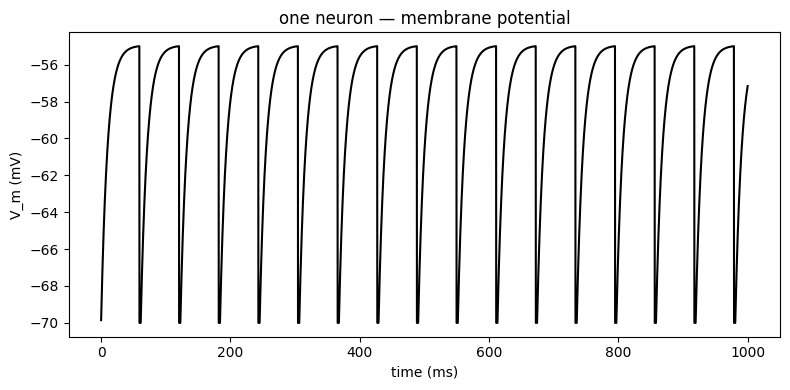

In [3]:
t = np.asarray(u.get_mantissa(res.times / u.ms))
v = np.asarray(u.get_mantissa(res.trace(vm, 'V_m') / u.mV)).reshape(-1)
n_spikes = int((np.diff(v) < -10.0).sum())   # threshold resets show as big drops
print(f'V_m: start {v[0]:.2f} mV, max {v.max():.2f} mV, {n_spikes} spikes in 1000 ms')

plt.figure(figsize=(8, 4))
plt.plot(t, v, color='k')
plt.xlabel('time (ms)'); plt.ylabel('V_m (mV)')
plt.title('one neuron — membrane potential')
plt.tight_layout()

## Driving the neuron with Poisson noise

Now replace the DC drive with a 2-channel `poisson_generator` — an excitatory channel and an inhibitory channel — with signed per-channel weights `[1.2, -1.0] pA`. The generator fans out one independent train per channel, and the per-channel weight vector applies one signed weight each, so the neuron integrates `1.2 · train_ex − 1.0 · train_in`. A passive `spike_recorder` lets us read the firing rate back.

In [4]:
sim = bp.Simulator(dt=0.1 * u.ms)
neuron = sim.create(bp.iaf_psc_alpha, 1)
noise = sim.create(bp.poisson_generator, 2, rate=[80000., 15000.] * u.Hz, rng_seed=0)
vm = sim.create(bp.voltmeter)
sr = sim.create(bp.spike_recorder)

sim.connect(noise, neuron, weight=[1.2, -1.0] * u.pA, delay=1.0 * u.ms)
sim.connect(vm, neuron)              # reversed analog tap
sim.connect(neuron, sr)             # the spike recorder taps the neuron

res = sim.simulate(1000. * u.ms)

In [5]:
v = np.asarray(u.get_mantissa(res.trace(vm, 'V_m') / u.mV)).reshape(-1)
print(f'V_m: mean {v.mean():.2f} mV, std {v.std():.2f} mV')
print(f'firing rate: {res.rate(sr):.2f} spks/s')

V_m: mean -61.25 mV, std 4.96 mV
firing rate: 47.00 spks/s


## See also

- [Populations & devices](02-populations.ipynb) — scale up to populations.
- [Model directory](../models.rst) — the neuron families.
- [Devices](../devices.rst) — generators, recorders, and detectors.
- [The State paradigm](../../concepts/state-paradigm.ipynb) — why `brainpy.state` makes state explicit and how the loop is lowered.